In [1]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import os

# ── Setup Cache ──────────────────────────────────────────
cache_dir = '../data/cache'
os.makedirs(cache_dir, exist_ok=True)
fastf1.Cache.enable_cache(cache_dir)

print("✅ FastF1 cache ready")

# ── Load 2024 Bahrain GP Race ─────────────────────────────
print("⏳ Loading 2024 Bahrain GP... (first load takes ~60 seconds)")

session = fastf1.get_session(2024, 'Bahrain', 'R')
session.load()

print(f"✅ Loaded: {session.event['EventName']}")
print(f"📅 Date: {session.date}")
print(f"📍 Location: {session.event['Location']}")

✅ FastF1 cache ready
⏳ Loading 2024 Bahrain GP... (first load takes ~60 seconds)


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

✅ Loaded: Bahrain Grand Prix
📅 Date: 2024-03-02 15:00:00
📍 Location: Sakhir


In [ ]:
# Get all laps from the race
laps = session.laps

print(f"📊 Total laps recorded: {len(laps)}")
print(f"🏎️  Drivers in race: {list(laps['Driver'].unique())}")
print()

# Show key lap info
print("Sample lap data:")
laps[['Driver', 'LapNumber', 'LapTime', 'Compound', 'TyreLife', 'Stint']].head(10)

📊 Total laps recorded: 1129
🏎️  Drivers in race: ['VER', 'PER', 'SAI', 'LEC', 'RUS', 'NOR', 'HAM', 'PIA', 'ALO', 'STR', 'ZHO', 'MAG', 'RIC', 'TSU', 'ALB', 'HUL', 'OCO', 'GAS', 'BOT', 'SAR']

Sample lap data:


,Driver,LapNumber,LapTime,Compound,TyreLife,Stint
0,VER,1.0,0 days 00:01:37.284000,SOFT,4.0,1.0
1,VER,2.0,0 days 00:01:36.296000,SOFT,5.0,1.0
2,VER,3.0,0 days 00:01:36.753000,SOFT,6.0,1.0
3,VER,4.0,0 days 00:01:36.647000,SOFT,7.0,1.0
4,VER,5.0,0 days 00:01:37.173000,SOFT,8.0,1.0
5,VER,6.0,0 days 00:01:37.092000,SOFT,9.0,1.0
6,VER,7.0,0 days 00:01:37.038000,SOFT,10.0,1.0
7,VER,8.0,0 days 00:01:37.024000,SOFT,11.0,1.0
8,VER,9.0,0 days 00:01:37.229000,SOFT,12.0,1.0
9,VER,10.0,0 days 00:01:36.960000,SOFT,13.0,1.0


In [8]:
# Get Hamilton's fastest lap
ham_laps = session.laps.pick_driver('HAM')
ham_fastest = ham_laps.pick_fastest()

print(f"⏱️  Hamilton's fastest lap: {ham_fastest['LapTime']}")
print(f"🔢  Lap number: {ham_fastest['LapNumber']}")
print(f"🏎️  Tyre compound: {ham_fastest['Compound']}")
print(f"🔄  Tyre life at this lap: {ham_fastest['TyreLife']} laps old")
print()

# Get telemetry for that lap
telemetry = ham_fastest.get_car_data().add_distance()

print(f"📡 Telemetry data points: {len(telemetry)}")
print()

# Show sample telemetry
telemetry[['Time', 'Speed', 'RPM', 'nGear', 'Throttle', 'Brake', 'Distance']].head(10)

⏱️  Hamilton's fastest lap: 0 days 00:01:34.722000
🔢  Lap number: 39.0
🏎️  Tyre compound: HARD
🔄  Tyre life at this lap: 6.0 laps old

📡 Telemetry data points: 345



/Users/sanjaychowdary/Downloads/F1 race intelligence/f1-env/lib/python3.13/site-packages/fastf1/core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,Time,Speed,RPM,nGear,Throttle,Brake,Distance
0,0 days 00:00:00.060000,295.0,10566.0,8,100.0,False,4.916667
1,0 days 00:00:00.339000,299.0,10701.0,8,100.0,False,28.089167
2,0 days 00:00:00.619000,301.0,10797.0,8,100.0,False,51.500278
3,0 days 00:00:00.980000,305.0,10913.0,8,100.0,False,82.085000
4,0 days 00:00:01.140000,307.0,10996.0,8,100.0,False,95.729444
5,0 days 00:00:01.380000,309.0,11031.0,8,100.0,False,116.329444
6,0 days 00:00:01.580000,311.0,11126.0,8,100.0,False,133.607222
7,0 days 00:00:02.020000,314.0,11171.0,8,100.0,False,171.985000
8,0 days 00:00:02.220000,315.0,11226.0,8,100.0,False,189.485000
9,0 days 00:00:02.500000,316.0,11387.0,8,100.0,False,214.062778


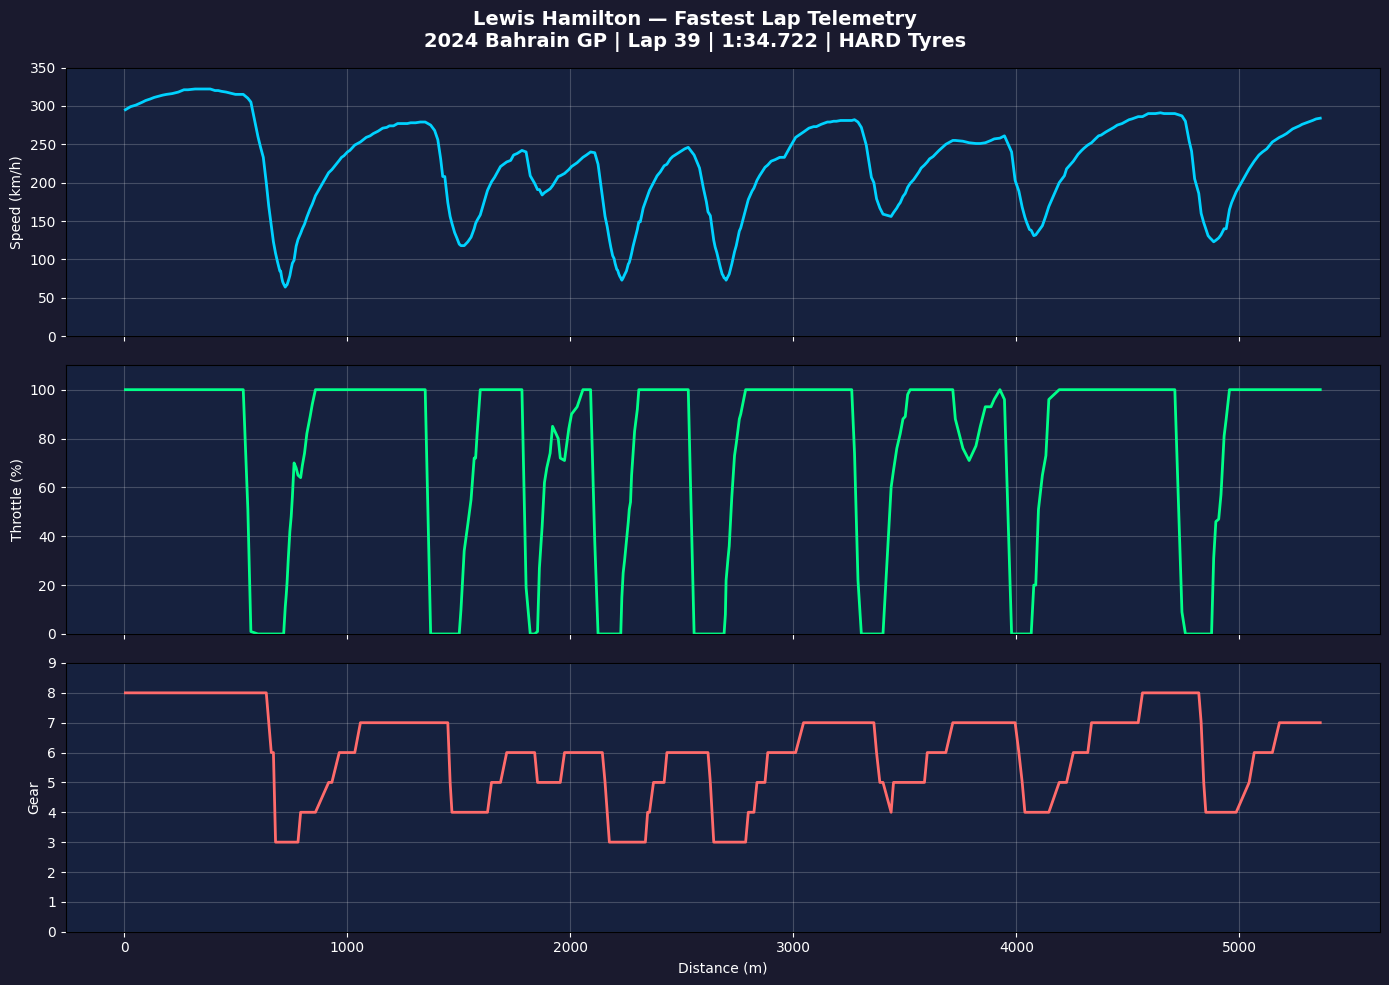

✅ Chart saved to data/ham_bahrain_telemetry.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Lewis Hamilton — Fastest Lap Telemetry\n2024 Bahrain GP | Lap 39 | 1:34.722 | HARD Tyres", 
             fontsize=14, fontweight='bold', color='white')
fig.patch.set_facecolor('#1a1a2e')

# ── Speed ──────────────────────────────────────
axes[0].plot(telemetry['Distance'], telemetry['Speed'], 
             color='#00d2ff', linewidth=2)
axes[0].set_ylabel('Speed (km/h)', color='white')
axes[0].set_facecolor('#16213e')
axes[0].tick_params(colors='white')
axes[0].grid(alpha=0.2, color='white')
axes[0].set_ylim(0, 350)

# ── Throttle ───────────────────────────────────
axes[1].plot(telemetry['Distance'], telemetry['Throttle'], 
             color='#00ff88', linewidth=2)
axes[1].set_ylabel('Throttle (%)', color='white')
axes[1].set_facecolor('#16213e')
axes[1].tick_params(colors='white')
axes[1].grid(alpha=0.2, color='white')
axes[1].set_ylim(0, 110)

# ── Gear ───────────────────────────────────────
axes[2].plot(telemetry['Distance'], telemetry['nGear'], 
             color='#ff6b6b', linewidth=2)
axes[2].set_ylabel('Gear', color='white')
axes[2].set_xlabel('Distance (m)', color='white')
axes[2].set_facecolor('#16213e')
axes[2].tick_params(colors='white')
axes[2].grid(alpha=0.2, color='white')
axes[2].set_ylim(0, 9)
axes[2].yaxis.set_major_locator(ticker.MultipleLocator(1))

plt.tight_layout()
plt.savefig('../data/ham_bahrain_telemetry.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print("✅ Chart saved to data/ham_bahrain_telemetry.png")

In [11]:
import numpy as np

# ── Get clean lap data with tire info ─────────────────────
tire_data = laps[[
    'Driver', 'LapNumber', 'LapTime', 
    'Compound', 'TyreLife', 'Stint',
    'TrackStatus', 'IsAccurate'
]].copy()

# ── Convert LapTime to seconds (easier for ML) ────────────
tire_data['LapTimeSeconds'] = tire_data['LapTime'].dt.total_seconds()

# ── Filter out dirty laps ─────────────────────────────────
# Remove: safety car laps, outlaps, inlaps, slow laps
tire_data = tire_data[
    (tire_data['IsAccurate'] == True) &          # Only accurate laps
    (tire_data['LapTimeSeconds'] > 85) &          # Remove crazy outliers
    (tire_data['LapTimeSeconds'] < 120) &         # Remove safety car laps
    (tire_data['Compound'].isin(['SOFT', 'MEDIUM', 'HARD']))  # Known compounds only
].dropna(subset=['LapTimeSeconds', 'TyreLife'])

print(f"✅ Clean laps for analysis: {len(tire_data)}")
print(f"📊 Compounds in data: {tire_data['Compound'].value_counts().to_dict()}")
print(f"👥 Drivers with clean data: {tire_data['Driver'].nunique()}")
print()
tire_data[['Driver', 'LapNumber', 'LapTimeSeconds', 'Compound', 'TyreLife', 'Stint']].head(10)

✅ Clean laps for analysis: 1024
📊 Compounds in data: {'HARD': 731, 'SOFT': 293}
👥 Drivers with clean data: 20



,Driver,LapNumber,LapTimeSeconds,Compound,TyreLife,Stint
1,VER,2.0,96.296,SOFT,5.0,1.0
2,VER,3.0,96.753,SOFT,6.0,1.0
3,VER,4.0,96.647,SOFT,7.0,1.0
4,VER,5.0,97.173,SOFT,8.0,1.0
5,VER,6.0,97.092,SOFT,9.0,1.0
6,VER,7.0,97.038,SOFT,10.0,1.0
7,VER,8.0,97.024,SOFT,11.0,1.0
8,VER,9.0,97.229,SOFT,12.0,1.0
9,VER,10.0,96.960,SOFT,13.0,1.0
10,VER,11.0,97.085,SOFT,14.0,1.0


In [12]:
import plotly.express as px
import plotly.graph_objects as go

# ── Average lap time by tyre life per compound ────────────
deg_curve = tire_data.groupby(['Compound', 'TyreLife'])['LapTimeSeconds'].median().reset_index()

fig = go.Figure()

colors = {'SOFT': '#FF3333', 'HARD': '#CCCCCC', 'MEDIUM': '#FFFF00'}

for compound in deg_curve['Compound'].unique():
    df = deg_curve[deg_curve['Compound'] == compound]
    fig.add_trace(go.Scatter(
        x=df['TyreLife'],
        y=df['LapTimeSeconds'],
        mode='lines+markers',
        name=compound,
        line=dict(color=colors.get(compound, 'white'), width=3),
        marker=dict(size=6)
    ))

fig.update_layout(
    title='Tire Degradation Curves — 2024 Bahrain GP',
    xaxis_title='Tyre Age (Laps)',
    yaxis_title='Median Lap Time (seconds)',
    template='plotly_dark',
    legend_title='Compound',
    height=500
)

fig.show()
print("✅ Degradation curves plotted")

✅ Degradation curves plotted


In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import numpy as np

# ── Feature Engineering ───────────────────────────────────
model_data = tire_data.copy()

# Encode compound as number
le = LabelEncoder()
model_data['CompoundEncoded'] = le.fit_transform(model_data['Compound'])

# Encode driver as number
le_driver = LabelEncoder()
model_data['DriverEncoded'] = le_driver.fit_transform(model_data['Driver'])

# Add tyre age squared (degradation is non-linear)
model_data['TyreLifeSquared'] = model_data['TyreLife'] ** 2

# Add interaction feature
model_data['CompoundAge'] = model_data['CompoundEncoded'] * model_data['TyreLife']

print("Features created:")
print(model_data[['Driver', 'Compound', 'TyreLife', 'TyreLifeSquared', 
                   'CompoundEncoded', 'DriverEncoded', 'LapTimeSeconds']].head())

# ── Define Features + Target ──────────────────────────────
features = [
    'TyreLife',
    'TyreLifeSquared', 
    'CompoundEncoded',
    'DriverEncoded',
    'CompoundAge',
    'LapNumber'
]

X = model_data[features]
y = model_data['LapTimeSeconds']

# ── Train / Test Split ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n✅ Training samples: {len(X_train)}")
print(f"✅ Test samples: {len(X_test)}")

Features created:
  Driver Compound  TyreLife  TyreLifeSquared  CompoundEncoded  DriverEncoded  \
1    VER     SOFT       5.0             25.0                1             18   
2    VER     SOFT       6.0             36.0                1             18   
3    VER     SOFT       7.0             49.0                1             18   
4    VER     SOFT       8.0             64.0                1             18   
5    VER     SOFT       9.0             81.0                1             18   

   LapTimeSeconds  
1          96.296  
2          96.753  
3          96.647  
4          97.173  
5          97.092  

✅ Training samples: 819
✅ Test samples: 205


In [14]:
# ── Train XGBoost Model ───────────────────────────────────
model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# ── Evaluate ──────────────────────────────────────────────
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"✅ Model trained successfully!")
print(f"📊 Mean Absolute Error: {mae:.3f} seconds")
print(f"📈 R² Score: {r2:.4f}")
print()

# Interpret results
print("📖 What this means:")
print(f"   → Model predicts lap time within ±{mae:.2f} seconds on average")
print(f"   → Model explains {r2*100:.1f}% of lap time variance")

if mae < 1.0:
    print("   → 🔥 Excellent! Sub 1-second accuracy is race-strategy grade")
elif mae < 2.0:
    print("   → ✅ Good accuracy for strategy predictions")
else:
    print("   → ⚠️ Needs more features — let's improve")

✅ Model trained successfully!
📊 Mean Absolute Error: 0.296 seconds
📈 R² Score: 0.8698

📖 What this means:
   → Model predicts lap time within ±0.30 seconds on average
   → Model explains 87.0% of lap time variance
   → 🔥 Excellent! Sub 1-second accuracy is race-strategy grade


In [15]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Feature Importance ────────────────────────────────────
importance = model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values('Importance', ascending=True)

# ── Actual vs Predicted ───────────────────────────────────
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

# ── Plot Both ─────────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'Feature Importance — What Drives Lap Time?',
        'Actual vs Predicted Lap Times'
    )
)

# Feature importance bar chart
fig.add_trace(go.Bar(
    x=feat_df['Importance'],
    y=feat_df['Feature'],
    orientation='h',
    marker_color='#00d2ff',
    name='Importance'
), row=1, col=1)

# Actual vs Predicted scatter
fig.add_trace(go.Scatter(
    x=comparison['Actual'],
    y=comparison['Predicted'],
    mode='markers',
    marker=dict(color='#ff6b6b', size=6, opacity=0.7),
    name='Predictions'
), row=1, col=2)

# Perfect prediction line
fig.add_trace(go.Scatter(
    x=[y_test.min(), y_test.max()],
    y=[y_test.min(), y_test.max()],
    mode='lines',
    line=dict(color='white', dash='dash', width=2),
    name='Perfect Prediction'
), row=1, col=2)

fig.update_layout(
    template='plotly_dark',
    height=450,
    title_text=f'XGBoost Tire Degradation Model — MAE: {mae:.3f}s | R²: {r2:.4f}',
    showlegend=False
)

fig.update_xaxes(title_text='Importance Score', row=1, col=1)
fig.update_xaxes(title_text='Actual Lap Time (s)', row=1, col=2)
fig.update_yaxes(title_text='Predicted Lap Time (s)', row=1, col=2)

fig.show()
print("✅ Model evaluation charts rendered")

✅ Model evaluation charts rendered


In [16]:
import joblib
import json
import os

# ── Save model ────────────────────────────────────────────
os.makedirs('../models', exist_ok=True)

joblib.dump(model, '../models/tire_degradation_model.pkl')
joblib.dump(le, '../models/compound_encoder.pkl')
joblib.dump(le_driver, '../models/driver_encoder.pkl')

# ── Save model metadata ───────────────────────────────────
metadata = {
    'model_type': 'XGBoost Regressor',
    'race': '2024 Bahrain Grand Prix',
    'mae_seconds': round(mae, 3),
    'r2_score': round(r2, 4),
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'features': features,
    'compounds': list(le.classes_),
    'drivers': list(le_driver.classes_)
}

with open('../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✅ Model saved to models/tire_degradation_model.pkl")
print("✅ Encoders saved")
print("✅ Metadata saved")
print()
print("📋 Model Summary:")
for k, v in metadata.items():
    print(f"   {k}: {v}")

✅ Model saved to models/tire_degradation_model.pkl
✅ Encoders saved
✅ Metadata saved

📋 Model Summary:
   model_type: XGBoost Regressor
   race: 2024 Bahrain Grand Prix
   mae_seconds: 0.296
   r2_score: 0.8698
   training_samples: 819
   test_samples: 205
   features: ['TyreLife', 'TyreLifeSquared', 'CompoundEncoded', 'DriverEncoded', 'CompoundAge', 'LapNumber']
   compounds: ['HARD', 'SOFT']
   drivers: ['ALB', 'ALO', 'BOT', 'GAS', 'HAM', 'HUL', 'LEC', 'MAG', 'NOR', 'OCO', 'PER', 'PIA', 'RIC', 'RUS', 'SAI', 'SAR', 'STR', 'TSU', 'VER', 'ZHO']
